# Solar Power Generation Data: KNN, Naive, Decision Tree and NN.
## Solar power generation and sensor data for two power plants.

Description
This data has been gathered at two solar power plants in India over a 34 day period. It has two pairs of files - each pair has one power generation dataset and one sensor readings dataset. The power generation datasets are gathered at the inverter level - each inverter has multiple lines of solar panels attached to it. The sensor data is gathered at a plant level - single array of sensors optimally placed at the plant.

There are a few areas of concern at the solar power plant -

- Can we predict the power generation for next couple of days? - this allows for better grid management
- Can we identify generation profiles?
- Can we identify the need for panel cleaning/maintenance?
- Can we identify faulty or suboptimally performing equipment?

[Link to source](https://www.kaggle.com/anikannal/solar-power-generation-data)
## Aluno: Zaú Júlio A. Galvão

In [1]:
import sys  

sys.path.append('../')

In [2]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor 
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

from read import (
    sourcesGen01Cleaned,
    groupsWeather01Cleaned,
)


## KNN

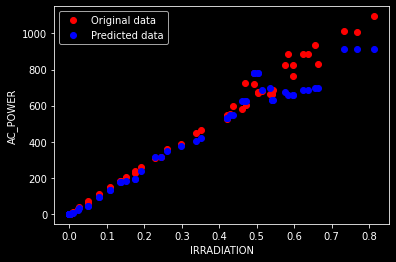

In [28]:
X = groupsWeather01Cleaned["IRRADIATION"].T
y = sourcesGen01Cleaned["AC_POWER"][list(sourcesGen01Cleaned["AC_POWER"].keys())[0]].T

X0 = X.iloc[0].values
y0 = y.iloc[0].values

X1 = X.iloc[1].values
y1 = y.iloc[1].values

plt.plot(X1, y1, 'o', color='red', label='Original data')
plt.xlabel("IRRADIATION")
plt.ylabel("AC_POWER")

neigh = KNeighborsRegressor(n_neighbors=3)
neigh.fit(X0.reshape(-1, 1), y0.astype(int))

pred = neigh.predict(X1.reshape(-1, 1))
knnScore = neigh.score(X0.reshape(-1, 1), y0.astype(int))

plt.plot(X1, pred, 'o', color='blue', label='Predicted data')
plt.legend()
plt.show()


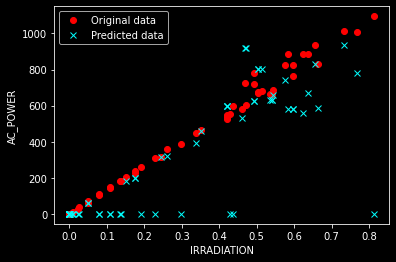

In [4]:
X = groupsWeather01Cleaned["IRRADIATION"].T
y = sourcesGen01Cleaned["AC_POWER"][list(sourcesGen01Cleaned["AC_POWER"].keys())[0]].T

X0 = X.iloc[0].values
y0 = y.iloc[0].values

X1 = X.iloc[1].values
y1 = y.iloc[1].values

plt.plot(X1, y1, 'o', color='red', label='Original data')
plt.xlabel("IRRADIATION")
plt.ylabel("AC_POWER")

model = GaussianNB(var_smoothing=1e-9)
model.fit(X0.reshape(-1, 1), y0.astype(int))

pred = model.predict(X1.reshape(-1, 1))
naiveBayesScore = model.score(X0.reshape(-1, 1), y0.astype(int))

plt.plot(X1, pred, 'x', color='cyan', label='Predicted data')
plt.legend()
plt.show()


## Decision Tree

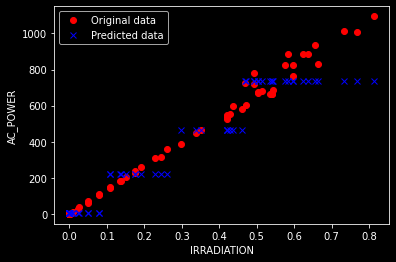

In [34]:
X = groupsWeather01Cleaned["IRRADIATION"].T
y = sourcesGen01Cleaned["AC_POWER"][list(sourcesGen01Cleaned["AC_POWER"].keys())[0]].T

X0 = X.iloc[0].values
y0 = y.iloc[0].values

X1 = X.iloc[1].values
y1 = y.iloc[1].values

plt.plot(X1, y1, 'o', color='red', label='Original data')
plt.xlabel("IRRADIATION")
plt.ylabel("AC_POWER")

model = DecisionTreeRegressor(random_state=0, criterion="mse", max_depth=5)
model.fit(X0.reshape(-1, 1), y0.astype(int))

pred = model.predict(X1.reshape(-1, 1))
treeScore = model.score(X0.reshape(-1, 1), y0.astype(int))

plt.plot(X1, pred, 'x', color='blue', label='Predicted data')
plt.legend()
plt.show()


## MLP

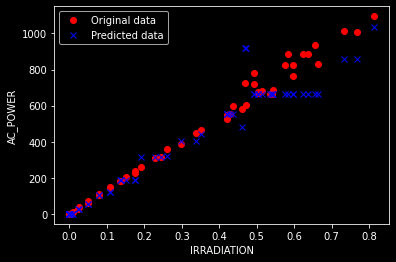

In [9]:
X = groupsWeather01Cleaned["IRRADIATION"].T
y = sourcesGen01Cleaned["AC_POWER"][list(sourcesGen01Cleaned["AC_POWER"].keys())[0]].T

X0 = X.iloc[0].values
y0 = y.iloc[0].values

X1 = X.iloc[1].values
y1 = y.iloc[1].values

plt.plot(X1, y1, 'o', color='red', label='Original data')
plt.xlabel("IRRADIATION")
plt.ylabel("AC_POWER")

model = MLPRegressor(
    hidden_layer_sizes=(10, 10),
    activation='tanh',
    solver='lbfgs',
    max_iter=10000
)

model.fit(X0.reshape(-1, 1), y0.astype(int))

pred = model.predict(X1.reshape(-1, 1))
mlpScore = model.score(X0.reshape(-1, 1), y0.astype(int))

plt.plot(X1, pred, 'x', color='blue', label='Predicted data')
plt.legend()
plt.show()

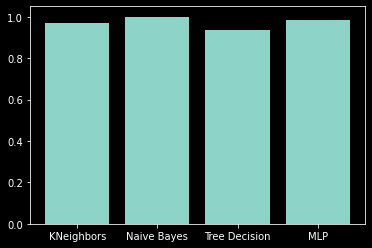

0.9694101468473443
1.0
0.9362003740221039
0.98498358811415


In [32]:
height = [knnScore, naiveBayesScore, treeScore, mlpScore]
bars = ('KNeighbors', 'Naive Bayes', 'Tree Decision', "MLP")
x_pos = np.arange(len(bars))
 
plt.bar(x_pos, height)
plt.xticks(x_pos, bars)
plt.show()

for i in height:    print(i)